In [ ]:
!uv add numpy
!uv add matplotlib
!uv add scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor as knn
from sklearn.linear_model import LinearRegression as lr
from sklearn.preprocessing import PolynomialFeatures as pf
from sklearn.metrics import mean_squared_error as mse

In [9]:
def f(x):
    return 2 * x + 5

def g(x):
    return 2 * x ** 3 - 4 * x ** 2 + 3 * x - 1

def h(x):
    return np.pi * x ** 6 + np.e * x ** 5 + np.sqrt(2) * x ** 2 - 17

def k(x):
    return 5 * np.cos(x)

FUNCTION_LABELS = {
    f: "2x + 5",
    g: "2x^3 - 4x^2 + 3x - 1",
    h: "πx^6 + ex^5 + √2x^2 - 17",
    k: "5 cos(x)",
}

def function_label(func):
    return FUNCTION_LABELS.get(func, func.__name__)

In [ ]:
# generate data as Y=f(X)+epsilon where f is a function and epsilon is "noise"

def generate_data(n_train, n_test, f):

    x_train = np.random.rand(n_train)
    x_test = np.random.rand(n_test)

    y_train = f(x_train) + np.random.randn(n_train)
    y_test = f(x_test) + np.random.randn(n_test)

    return x_train, y_train, x_test, y_test

In [11]:
# fit prediction methods with increasing complexity (k-nearest neighbour and polynomial regression)

def fit_predict_knn(x_train, y_train, x_test, y_test, k):
    model = knn(n_neighbors=k)
    model.fit(x_train.reshape(-1, 1), y_train)
    y_pred_train = model.predict(x_train.reshape(-1, 1))
    y_pred_test = model.predict(x_test.reshape(-1, 1)) 
    return y_pred_train, y_pred_test

def fit_predict_poly(x_train, y_train, x_test, y_test, degree):
    poly = pf(degree=degree)
    x_train_poly = poly.fit_transform(x_train.reshape(-1, 1))
    x_test_poly = poly.fit_transform(x_test.reshape(-1, 1))
    model = lr()
    model.fit(x_train_poly, y_train)
    y_pred_train = model.predict(x_train_poly)
    y_pred_test = model.predict(x_test_poly)
    return y_pred_train, y_pred_test

In [12]:
# measure the empirical mean of the training error in dependence of the complexity parameters (the mean is computed over several samples with the same distribution)
# generate a test set with the same distribution and compute the empirical mean of the test error in dependence of the complexity parameter


def _measure_single_model(f, n_train, n_test, complexity_values, predictor, n_samples=10):
    train_means = []
    test_means = []

    for value in complexity_values:
        train_errors = np.empty(n_samples)
        test_errors = np.empty(n_samples)

        for sample_idx in range(n_samples):
            x_train, y_train, x_test, y_test = generate_data(n_train, n_test, f)
            y_pred_train, y_pred_test = predictor(x_train, y_train, x_test, y_test, value)
            train_errors[sample_idx] = mse(y_train, y_pred_train)
            test_errors[sample_idx] = mse(y_test, y_pred_test)

        train_means.append(train_errors.mean())
        test_means.append(test_errors.mean())

    return np.asarray(train_means), np.asarray(test_means)


def measure_error(f, n_train, n_test, k_values=None, degree_values=None, n_samples=10):
    results = {}

    if k_values is not None:
        knn_train_mean, knn_test_mean = _measure_single_model(
            f, n_train, n_test, k_values, fit_predict_knn, n_samples
        )
        results["knn"] = {
            "complexity": np.asarray(k_values),
            "train_mean": knn_train_mean,
            "test_mean": knn_test_mean,
        }

    if degree_values is not None:
        poly_train_mean, poly_test_mean = _measure_single_model(
            f, n_train, n_test, degree_values, fit_predict_poly, n_samples
        )
        results["poly"] = {
            "complexity": np.asarray(degree_values),
            "train_mean": poly_train_mean,
            "test_mean": poly_test_mean,
        }

    return results

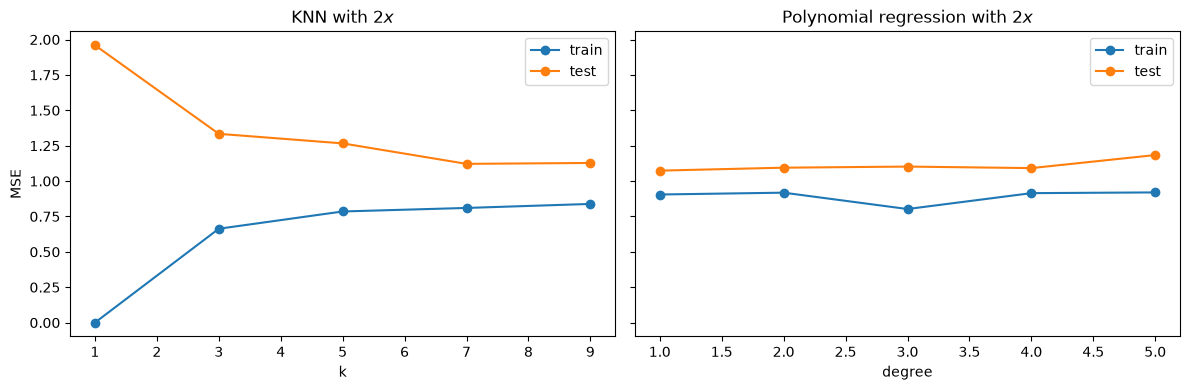

In [13]:
# Example plot
def two_x(x):
    return 2 * x

results = measure_error(
    two_x,
    n_train=50,
    n_test=200,
    k_values=[1, 3, 5, 7, 9],
    degree_values=[1, 2, 3, 4, 5],
    n_samples=20,
)

data_label = "2x"

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(results["knn"]["complexity"], results["knn"]["train_mean"], marker="o", label="train")
axes[0].plot(results["knn"]["complexity"], results["knn"]["test_mean"], marker="o", label="test")
axes[0].set_title(f"KNN with ${data_label}$")
axes[0].set_xlabel("k")
axes[0].set_ylabel("MSE")
axes[0].legend()

axes[1].plot(results["poly"]["complexity"], results["poly"]["train_mean"], marker="o", label="train")
axes[1].plot(results["poly"]["complexity"], results["poly"]["test_mean"], marker="o", label="test")
axes[1].set_title(f"Polynomial regression with ${data_label}$")
axes[1].set_xlabel("degree")
axes[1].legend()

plt.tight_layout()

In [14]:
# represent the results through one or more pictures

def plot_results(results, data_label):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    axes[0].plot(results["knn"]["complexity"], results["knn"]["train_mean"], label="train error")
    axes[0].plot(results["knn"]["complexity"], results["knn"]["test_mean"], label="test error")
    axes[0].set_title(f"KNN with ${data_label}$")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("MSE")
    axes[0].legend()

    axes[1].plot(results["poly"]["complexity"], results["poly"]["train_mean"], label="train error")
    axes[1].plot(results["poly"]["complexity"], results["poly"]["test_mean"], label="test error")
    axes[1].set_title(f"Polynomial regression with ${data_label}$")
    axes[1].set_xlabel("degree")
    axes[1].legend()

    plt.tight_layout()

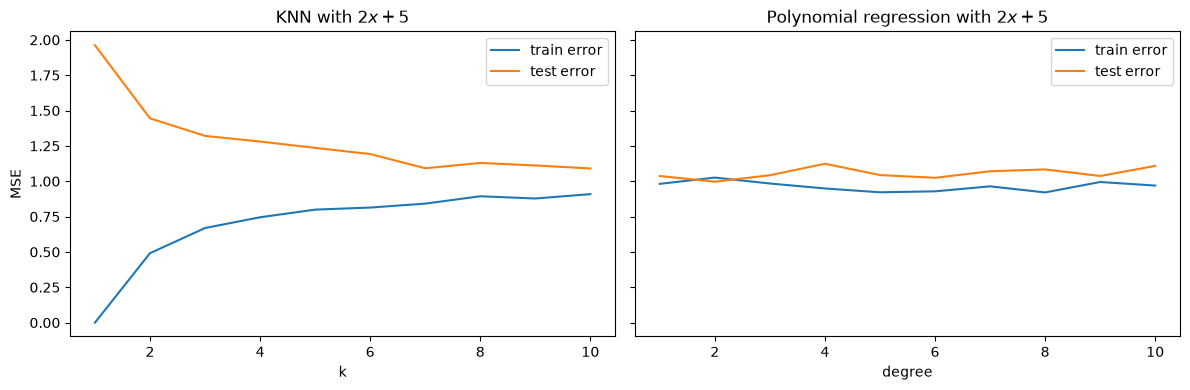

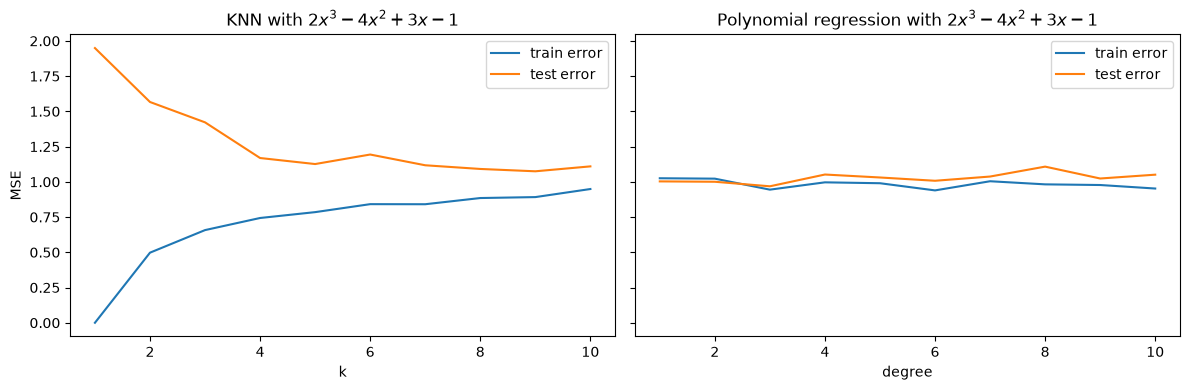

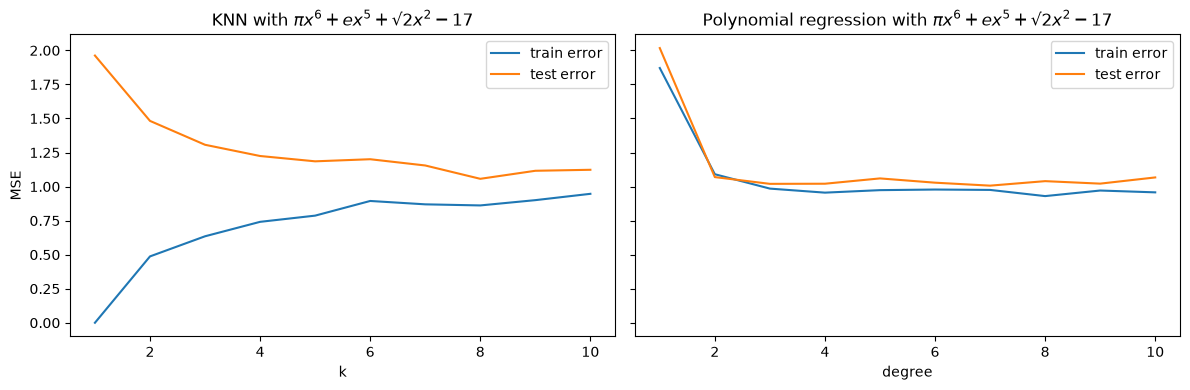

In [16]:
# run the whole pipeline for all the functions

for func in [f, g, h]:  
    data_label = function_label(func)
    results = measure_error(
        func,
        n_train=200,
        n_test=100,
        k_values=range(1, 11),
        degree_values=range(1, 11),
        n_samples=20,
    )
    plot_results(results, data_label)